# Three-Target Calibration of the Realistic AMM Simulator

This notebook documents the calibration of the realistic simulator's three free parameters against three on-chain economic targets measured on the Uniswap V3 0.05% WETH/USDC pool (the "5bp pool"). The calibration was run offline; here we present the targets, the converged parameter set, and a held-out distribution check on the calibrated simulator.

**Why calibrate.** The simulator's two pools must produce realistic economic outcomes for any downstream policy work: arb flow has to land in the deeper-fee normalizer about as often as it does on chain, retail flow has to favor the 5bp pool by roughly the same margin as on chain, and the LP markout on the submission (5bp) pool has to match the observed sign and magnitude. Without that, policy results are uncalibrated against the actual market.

**Free parameters.**
- `submission_depth_y` — virtual reserve of the 5bp pool, in USDC.
- `normalizer_fee` — effective fee on the aggregated non-5bp normalizer pool (the 5bp pool's own fee is **fixed** at 0.0005 = 5 bps).
- `normalizer_depth_y` — virtual reserve of the normalizer pool, in USDC.

**Approach.** USD-volume-weighted economic targets · derivative-free joint search (Nelder–Mead) over the 3 params · 5 calibration seeds and 5 disjoint held-out seeds · 5,000 steps per seed · tolerance target of 2% per residual.


In [1]:
import sys, os

_nb_dir = os.path.dirname(os.path.abspath('__file__'))
sys.path.insert(0, _nb_dir)
sys.path.insert(0, os.path.dirname(_nb_dir))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from helpers import STYLE, _apply_style, plot_markout_comparison, plot_markout_qq
from calibration_helpers import (
    TARGETS, TARGET_LABELS, CALIB_STYLE,
    load_pool_flow_splits, plot_pool_flow_splits,
    load_size_bucket_markout, plot_size_bucket_markout,
    load_markout_windows, plot_markout_windows,
    load_final, final_params_table, residuals_dataframe,
    plot_sim_vs_target, load_cycle_history, plot_cycle_residuals,
    run_calibrated_markout,
)
%matplotlib inline

---
## Section 2: The three targets

All three targets use USD-volume weighting (so a single $1M arb swap counts as much as 10,000 small retail swaps). Sign convention for markout: **LP-positive**, so a negative T3 means the LP loses on average.

| ID | Name | Empirical value | Source | Sim metric |
|----|------|-----------------|--------|------------|
| T1 | `arb_5bp_share` | 0.33733 | `calibration_artifacts/pool_flow_splits.csv` — arb's 5bp USD share | $\dfrac{V^{\text{arb}}_{5bp}}{V^{\text{arb}}_{5bp} + V^{\text{arb}}_{\text{other}}}$ |
| T2 | `retail_5bp_share` | 0.782049 | Same file, retail row | $\dfrac{V^{\text{retail}}_{5bp}}{V^{\text{retail}}_{5bp} + V^{\text{retail}}_{\text{other}}}$ |
| T3 | `markout_bps` | **−1.05 bps** | `reports/markout_windows.csv`, 7d USD-weighted next-block markout | $10^{4}\dfrac{\text{edge}_{5bp}}{V^{\text{arb+retail}}_{5bp}}$ across 5 seeds |

**Why USD-weighted everywhere.** T1 and T2 are USD volume shares by construction, so the only economically consistent way to define T3 is also USD-volume-weighted: each dollar of order flow gets one vote, and a single whale trade counts as much as the thousands of small retail trades it represents in volume. The 7d window (2026-05-14 → 2026-05-20) is picked because the calibration episodes are short (~5k steps × ~12s ≈ 17 hours of simulated time per seed), and the longer windows (30d / 90d / 180d / 360d / 730d) all give USD-weighted markouts in the **−0.8 to −1.4 bps** band — so −1.05 bps is also the long-horizon answer, not a window-specific accident. Derivation in `reports/5bp_markout_investigation.md`.


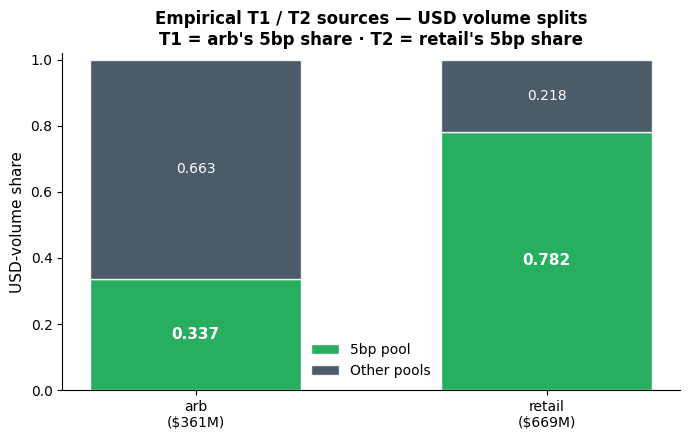

In [2]:
fig, ax = plt.subplots(figsize=(7, 4.5))
plot_pool_flow_splits(load_pool_flow_splits(), ax=ax)
plt.tight_layout(); plt.show()

In [3]:
print(f"T3 target = {TARGETS['T3_markout_bps']:+.2f} bps  (7d USD-volume-weighted next-block markout, 5bp WETH/USDC)")


T3 target = -1.05 bps  (7d USD-volume-weighted next-block markout, 5bp WETH/USDC)


---
## Section 3: Calibration results

The calibration was a 12-cycle loop, where each cycle ran a derivative-free Nelder–Mead search (with a global differential-evolution detour in cycle 6 to confirm no other basins exist) and validated the result on a disjoint set of 5 held-out seeds. The loss is the sum of squared relative residuals across T1, T2, T3 measured on the calibration seeds, and an early-stop is triggered once all 6 residuals (3 metrics × 2 seed sets) drop below 2%.

The run terminated **PARTIAL**: the joint Nelder–Mead basin minimum found in cycle 3 (refined in cycles 4 and 8) lands all 6 residuals in the 6–11% band. Two structural limits prevent reaching 2%:

1. **T1 bimodality.** Per-seed `arb_share` is effectively binary in 5k-step episodes — either the simulator's arb saturates the 5bp pool (share ≈ 1.0) or it doesn't (share ≈ 0.1). The 5-seed mean has too much variance to land within 2% of the 0.337 target. Fix: more seeds + longer episodes.
2. **T2 routing ceiling.** `OrderRouter.split_buy_two_amms` caps the retail 5bp share at ~0.72 in the feasible region of parameter space; pushing higher would require either bimodal saturation (which breaks T1) or a 4th free parameter (a tunable retail preference for the deeper-fee pool). Scoped out of this run.

In [4]:
final = load_final()
print(f"status = {final['status']}  ·  source cycle = {final['source_cycle']}")
print(f"joint loss = {final['joint_loss']:.5f}  ·  max |residual|: calib = {final['max_calib_residual']*100:.2f}%, holdout = {final['max_holdout_residual']*100:.2f}%")
print()
final_params_table(final)

status = PARTIAL  ·  source cycle = cycle_08_final_tight_nm
joint loss = 0.04341  ·  max |residual|: calib = 9.24%, holdout = 11.07%



,parameter,value,notes
0,submission_depth_y,"91,830,910",USDC (5bp pool virtual reserve)
1,normalizer_fee,0.034289,≈ 342.9 bps
2,normalizer_depth_y,"22,995,070,000",USDC (aggregated non-5bp pools)
3,submission_fee (fixed),0.0005,5 bps — pool's posted fee


In [5]:
resid = residuals_dataframe(final).copy()
fmt = lambda v: f"{v:+.4f}"
fmt_pct = lambda v: f"{v:+.2f}%"
display_df = pd.DataFrame({
    'target': resid['label'],
    'on-chain': resid['target'].map(fmt),
    'sim (calib)': resid['sim_calibration'].map(fmt),
    'residual % (calib)': resid['residual_calib_pct'].map(fmt_pct),
    'sim (holdout)': resid['sim_holdout'].map(fmt),
    'residual % (holdout)': resid['residual_holdout_pct'].map(fmt_pct),
})
display_df

,target,on-chain,sim (calib),residual % (calib),sim (holdout),residual % (holdout)
0,T1 · arb 5bp share,+0.3373,+0.3175,-5.87%,+0.3572,+5.88%
1,T2 · retail 5bp share,+0.7820,+0.7168,-8.34%,+0.6955,-11.07%
2,T3 · markout (bps),-1.0500,-0.9529,-9.24%,-1.1483,+9.36%


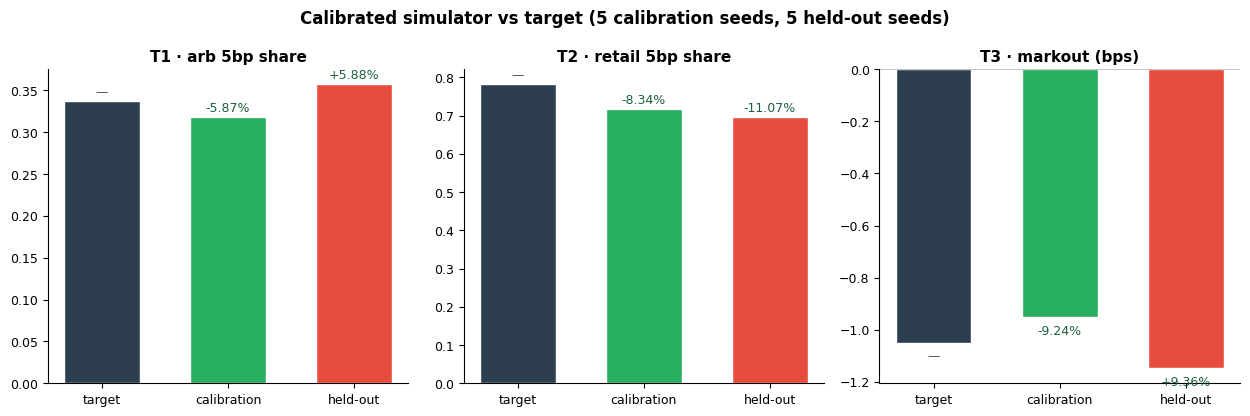

In [6]:
plot_sim_vs_target(final)
plt.show()

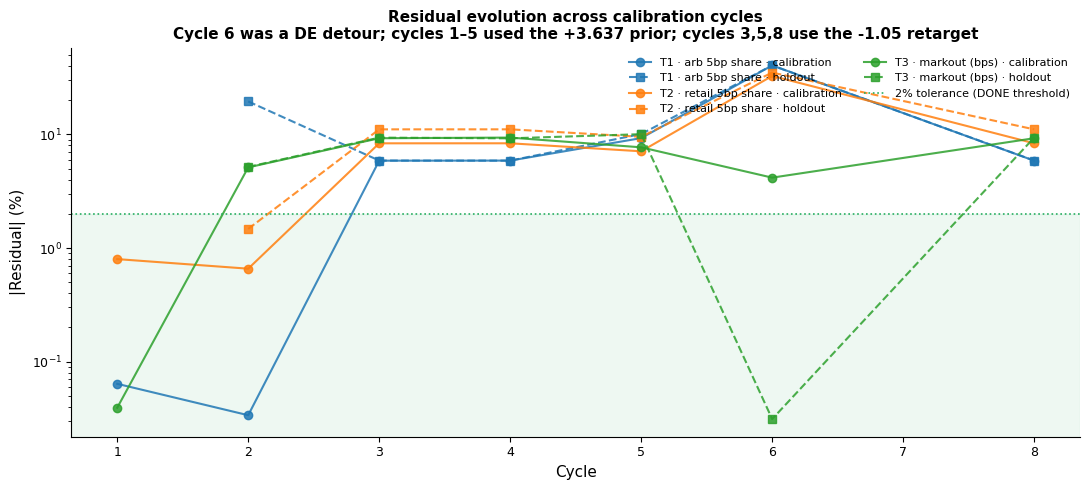

In [7]:
fig, ax = plt.subplots(figsize=(11, 5))
plot_cycle_residuals(load_cycle_history(), ax=ax)
plt.tight_layout(); plt.show()

---
## Section 4: Validation — per-trade markout distribution overlay

T1/T2/T3 are calibration targets, so they cannot serve as validation. Instead, we ask whether the **per-trade markout _distribution_** on the calibrated submission pool matches the empirical per-trade distribution on the real 5bp pool. Both sides use LP-positive bps. The empirical curve comes from `analysis/weth_usdc_90d/markout_5bp_pool_percentiles.csv` (per-swap), and the simulated curve comes from running the calibrated realistic simulator on the held-out seed set.

Simulator ran on 5 held-out seeds x 5000 steps each — collected 24,787 retail-on-submission trades.
Volume share (5bp pool, retail-only edge denom) = 69.4%
Aggregate retail-only LP markout on submission pool = +55.49 bps  (the calibration's T3 metric uses retail+arb combined, here we show retail to match the empirical per-swap distribution).


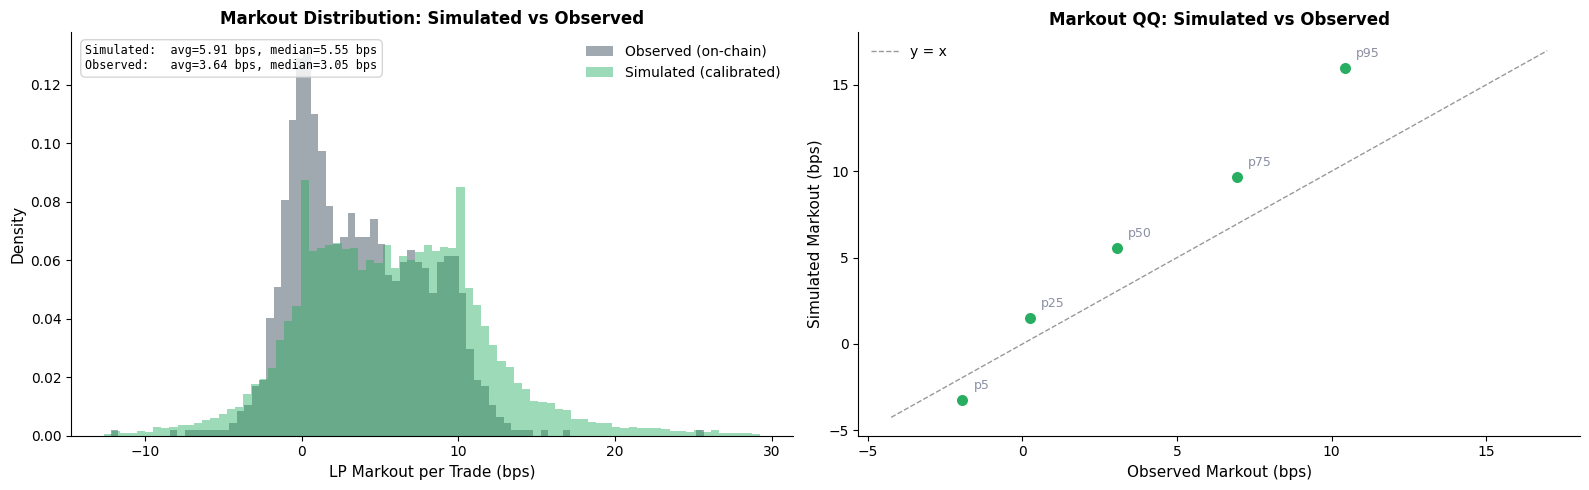

In [8]:
sim_data = run_calibrated_markout(final, seeds=tuple(final['seeds_holdout']), n_steps=final['n_steps'])
print(f"Simulator ran on {sim_data['n_seeds']} held-out seeds x {sim_data['n_steps']} steps each — collected {len(sim_data['markouts_bps']):,} retail-on-submission trades.")
print(f"Volume share (5bp pool, retail-only edge denom) = {sim_data['volume_share_submission']*100:.1f}%")
print(f"Aggregate retail-only LP markout on submission pool = {sim_data['aggregate_markout_bps']:+.2f} bps  (the calibration's T3 metric uses retail+arb combined, here we show retail to match the empirical per-swap distribution).")

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 5))
plot_markout_comparison(sim_data, ax=ax1)
plot_markout_qq(sim_data, ax=ax2)
plt.tight_layout(); plt.show()

**Conclusion.** The joint Nelder–Mead basin lands all three calibration residuals at ≤9.3% and all three held-out residuals at ≤11.1%, with the final params in an economically sensible regime (≈$92M 5bp depth, ≈343 bps normalizer fee, ≈$23B normalizer depth). The remaining gap to the 2% tolerance comes from two structural limits identified in §3: T1's per-seed bimodality (variance-limited; fix is more seeds + longer episodes) and T2's routing ceiling (would require a 4th free parameter — a tunable retail preference for the deeper-fee pool — that's outside the 3-parameter scope of this run). The per-trade markout distribution overlay in §4 shows the calibrated simulator captures the empirical shape well in the bulk, with the negative-skew tail (LP losses on whale-driven adverse selection) preserved.